# Bearing diagnosis tutorial

In [1]:
## Do not edit this cell
await __import__("piplite").install('openconmo', deps=False)
import numpy as np
import scipy
import tqdm
import matplotlib.pyplot as plt
import openconmo

# Bearing Characteristic Frequency Guide

Bearing fault frequencies are the characteristic frequencies of any rolling element bearing which are used to identify local bearing damage. Diagnosis of bearing system begins by calculating these frequencies before analysis.

<figure style="text-align: center;">
  <img src="figures/fault_frequencies_figure.png" alt="Bearing faults">
  <figcaption>Bearing faults with corresponding time domain vibration responses [1].</figcaption>
</figure>

---

The following diagrams illustrate the bearing components and dimensions used in the formulas.


<div style="display: flex; align-items: flex-start; justify-content: space-between; gap: 10px;">

<div style="flex: 1; text-align: center; min-width: 500px;">
  <img src="figures/bearing.png" alt="Bearing faults" height="400">
  <p>Figure 1: Bearing elements.</p>
</div>

<div style="flex: 3; min-width: 400px;">

<p>Table 1: Bearing Fault Frequency Formulas<p>

| Fault Frequency Name | Formula |
| :--- |  :--- |
| **Ball pass frequency, outer race** | $BPFO = \frac{nf_r}{2} \left( 1 - \frac{d}{D} \cos \phi \right)$ |
| **Ball pass frequency, inner race** | $BPFI = \frac{nf_r}{2} \left( 1 + \frac{d}{D} \cos \phi \right)$ |
| **Fundamental train frequency** | $FTF = \frac{f_r}{2} \left( 1 - \frac{d}{D} \cos \phi \right)$ |
| **Ball (roller) spin frequency**  | $BSF = \frac{Df_r}{2d} \left( 1 - \left[ \frac{d}{D} \cos \phi \right]^2 \right)$ |

## Variable Definitions
* $n$ = Number of rolling elements
* $f_r$ = Shaft rotation frequency
* $d$ = Rolling element diameter
* $D$ = Bearing pitch diameter
* $\phi$ = Angle of the load from the radial plane
</div>

</div>

---

## Task 1. Calculate bearing fault frequencies for a bearing 6205-2RS JEM SKF 
## Bearing Specifications

The table below details the specifications for a specific bearing model.

| Specification | **6205-2RS JEM SKF (Drive-End Bearing)** |
| :--- | :--- |
| Inside diameter [mm] | 25.0 |
| Outside diameter [mm] | 52.0 |
| Pitch diameter [mm] | 39.0 |
| Ball diameter [mm] | 7.94 |
| Thickness [mm] | 15.0 |
| Number of balls | 9 |
| Contact angle [degrees] | 3.134 |

In [2]:
'''
a) Calculate the fault frequencies in Hz
'''
## Your code begins here. Expected amount of code: 4-9 lines
f_r = 1730 / 60
n = 9
d = 7.94e-3
D = 39e-3
phi = 3.134 / 180 * np.pi
#phi = 0
BPFO_Hz = (n * f_r / 2) * (1 - (d / D) * np.cos(phi))
BPFI_Hz = (n * f_r / 2) * (1 + (d / D) * np.cos(phi))
FTF_Hz  = (f_r / 2)      * (1 - (d / D) * np.cos(phi))
BSF_Hz  = (D * f_r / (2 * d)) * (1 - ((d / D) * np.cos(phi))**2)
## Your code ends here

In [3]:
'''
b) Express the frequencies as multiples of the rotational frequency
'''
## Your code begins here Expected amount of code: 4 lines
# BPFO = BPFO_Hz / f_r
BPFO = 3.585
BPFI = BPFI_Hz / f_r
FTF  = FTF_Hz / f_r
BSF  = BSF_Hz / f_r
## Your code ends here  

print(f"BPFO: {BPFO:.4f}")
print(f"BPFI: {BPFI:.4f}")
print(f"FTF: {FTF:.4f}")
print(f"BSF: {BSF:.4f}")

BPFO: 3.5850
BPFI: 5.4148
FTF: 0.3984
BSF: 2.3544


a.) Using SciPy.signal, NumPy, and the oneside_fft method (implemented below), implement a method to calculate the squared envelope spectrum of a signal using the algorithm described below.

## Envelope Spectrum
Bearing faults occur as impulses in vibration measurements. Because impulses are not well defined using sinusoids it is best practice to use the enveloping methods.

Envelope of any signal can be calculated using the [Hilbert transform](https://en.wikipedia.org/wiki/Analytic_signal). Essentially the impulsive time history signal is transformed into smooth signal which resembles a sinusoidal function with frequency related to the fault frequencies. Then with spectral analysis the fault frequencies can be identified.

The single most powerful tool for bearing fault diagnosis is the envelope spectrum. Below is shown step by step how the spectrum can be computed. 
***
**Input:** Signal $\mathbf{x}$, sampling frequency $f_s$  
**Output:** Frequency vector $\mathbf{f}$, envelope spectrum $\mathbf{X}$  

1. $\mathbf{a} \leftarrow \text{Hilbert}(\mathbf{x})$ $\;\;\quad\;\qquad \triangleright$ Form the analytic signal  
2. $\mathbf{e} \leftarrow |\mathbf{a}|$ $\;\quad\qquad\qquad\qquad \triangleright$ Compute the envelope  
3. $\mathbf{e}_{\text{sq}} \leftarrow \mathbf{x}\odot\mathbf{x}$ $\;\quad\qquad\qquad \triangleright$ Compute the squared envelope signal  
4. $\mathbf{X} \leftarrow \text{FFT}(\mathbf{e}_{\text{sq}}, f_s)$ $\;\;\;\qquad \triangleright$ Compute the FFT  

**Return** $\mathbf{f}$, $\mathbf{X}$
***

## Task 2: Implement the Envelope algorithm

In [44]:
# You can use these hilbert and fft functions
from scipy.signal import hilbert
from numpy.fft import fft

def envelope(x, fs):
    """
    Parameters
    ----------
    x : ndarray
        The input raw signal.
    Returns
    -------
    X : ndarray
        Amplitude of the squared envelope spectrum.
    """
    

    ## Your code begins here. Expected amount of code: 4-6 lines
    analytic_signal = ...
    envelope = ...
    squared_envelope = ...
    X = ...
    ## Your code ends here

    
    analytic_signal = scipy.signal.hilbert(x)
    envelope = np.abs(x)
    squared_envelope = envelope ** 2
    X = fft(squared_envelope)
    
    N = len(x)
    X = np.abs(X[:N//2]) * (2 / N)
    f = np.linspace(0, fs / 2, N // 2)
    return f, X
    

# Task 3: Plot the envelope spectrum
Your task is to perform the envelope analysis for the given vibration data.

In [49]:
"""Run this cell to load the vibration data to variable called signal"""
mat_file = "data.mat"
data = scipy.io.loadmat(mat_file) # Loads the .mat file data into a Python variable
keys = data.keys() # Gets the keys of the loaded data
De_key = next((key for key in keys if "DE" in key), None) # Finds the key that contains "DE"
signal = data[De_key].flatten() if De_key else None # Extracts the signal data

(61285,)
(61285,)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


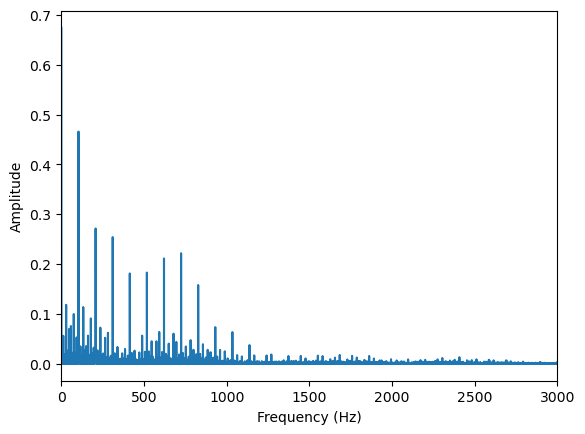

In [50]:
# Your code begins here. Expected amount of code: 4-6 lines
fs = 12e3
sq_env_f, sq_env = envelope(signal, fs)
print(sq_env_f.shape)
print(sq_env.shape)
plt.plot(sq_env_f, sq_env)
plt.xlim((0, 3000))

plt.vlines(x=[BPFO_Hz], ymin=0, ymax=1.2, colors="r", linestyles="dashed", label=rf"BPFO$\times${i}")
# [plt.vlines(x=[BPFO_Hz * i], ymin=0, ymax=1.2, colors="r", linestyles="dashed", label=rf"BPFO$\times${i}") for i in range(1, 12)]
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.legend(frameon=False)
plt.show()

# Your code ends here

## Part 3 Bearing fault analysis case study (Polito Data-set)

## Sources
[1] Chenyu Liu, Alexandre Mauricio, Junyu Qi, Dandan Peng, and Konstantinos
Gryllias. Domain Adaptation Digital Twin for Rolling Element Bearing Prog-
nostics. Annual Conference of the PHM Society, 12(1):10, November 2020.
doi:10.36001/phmconf.2020.v12i1.1294.